# Week 2: Transfer Learning with InceptionV3

This notebook implements all the concepts from Week 2 notes.

## Topics Covered:
1. Transfer Learning Introduction
2. Understanding Transfer Learning Concepts
3. Coding Transfer Learning from Inception
4. Building Custom Models with Transferred Features
5. Exploring Dropouts
6. Complete Implementation
7. Practical Walkthrough
8. Results and Analysis

## Setup and Imports

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2025-10-08 16:08:02.586136: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-08 16:08:02.670958: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-08 16:08:04.386483: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0
GPU Available: []


2025-10-08 16:08:05.269530: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Understanding Transfer Learning

Transfer learning allows us to leverage pre-trained models instead of training from scratch.

### Key Benefits:
- Less data required (thousands vs millions)
- Faster training (hours vs weeks)
- Better accuracy with limited data
- Lower computational cost

## 2. Load Pre-trained InceptionV3

InceptionV3 was trained on ImageNet with:
- 1.4 million images
- 1,000 different classes
- Weeks of training time

In [2]:
# Configuration
IMG_SHAPE = (150, 150, 3)

# Option 1: Load with pre-downloaded weights
# local_weights_file = 'inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

# Initialize InceptionV3 without top layers
base_model = InceptionV3(
    input_shape=IMG_SHAPE,
    include_top=False,      # Exclude the ImageNet classifier
    weights='imagenet'      # Use ImageNet pre-trained weights
)

# Option 1b: If using local weights
# base_model = InceptionV3(input_shape=IMG_SHAPE, include_top=False, weights=None)
# base_model.load_weights(local_weights_file)

print(f"Base model loaded successfully!")
print(f"Total layers: {len(base_model.layers)}")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Base model loaded successfully!
Total layers: 311


## 3. Freeze the Base Model

Freezing prevents the pre-trained weights from being updated during training.

In [3]:
# Freeze all layers in the base model
base_model.trainable = False

# Verify freezing
print(f"Base model trainable: {base_model.trainable}")
print(f"Number of trainable layers: {sum([layer.trainable for layer in base_model.layers])}")

# Check a few layers
print("\nFirst 5 layers:")
for i, layer in enumerate(base_model.layers[:5]):
    print(f"  {layer.name}: trainable={layer.trainable}")

Base model trainable: False
Number of trainable layers: 0

First 5 layers:
  input_layer: trainable=False
  conv2d: trainable=False
  batch_normalization: trainable=False
  activation: trainable=False
  conv2d_1: trainable=False


## 4. Select Output Layer

We'll use 'mixed7' layer which provides a good balance of:
- Generalized features
- 7×7 spatial resolution
- 768 feature channels

In [4]:
# Get the 'mixed7' layer output
last_layer = base_model.get_layer('mixed7')
print(f"Selected layer: {last_layer.name}")
print(f"Output shape: {last_layer.output.shape}")

last_output = last_layer.output

Selected layer: mixed7
Output shape: (None, 7, 7, 768)


## 5. Build Custom Classification Head

Add trainable layers on top of the frozen base for binary classification.

In [5]:
# Build the custom classification head
x = layers.Flatten()(last_output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.2)(x)  # Dropout for regularization
x = layers.Dense(1, activation='sigmoid')(x)  # Binary classification

# Create the complete model
model = Model(base_model.input, x)

print("\nModel architecture:")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]):,}")

2025-10-08 16:10:11.377532: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 154140672 exceeds 10% of free system memory.
2025-10-08 16:10:11.416122: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 154140672 exceeds 10% of free system memory.
2025-10-08 16:10:11.436185: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 154140672 exceeds 10% of free system memory.



Model architecture:
Total parameters: 47,512,481
Trainable parameters: 38,537,217
Non-trainable parameters: 8,975,264


## 6. Compile the Model

Use:
- RMSprop optimizer with low learning rate (0.0001)
- Binary crossentropy loss
- Accuracy metric

In [6]:
# Compile the model
model.compile(
    optimizer=RMSprop(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## 7. Prepare Dataset

**IMPORTANT**: Update the paths below to match your dataset location.

Expected structure:
```
data/
├── train/
│   ├── cats/
│   └── dogs/
└── validation/
    ├── cats/
    └── dogs/
```

In [7]:
# Dataset paths - UPDATE THESE!
BASE_DIR = '../data/cats_and_dogs_filtered'  # UPDATE THIS PATH
train_dir = os.path.join(BASE_DIR, 'train')
validation_dir = os.path.join(BASE_DIR, 'validation')

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"⚠️ WARNING: Training directory not found at {train_dir}")
    print("Please update BASE_DIR to point to your dataset")
else:
    print(f"✓ Training directory found: {train_dir}")
    print(f"✓ Validation directory found: {validation_dir}")

✓ Training directory found: ../data/cats_and_dogs_filtered/train
✓ Validation directory found: ../data/cats_and_dogs_filtered/validation


## 8. Create Data Generators

### Critical: InceptionV3 Preprocessing
InceptionV3 requires inputs scaled to [-1, 1] range.

In [8]:
# Load datasets using TensorFlow's built-in method
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150, 150),
    batch_size=20,
    label_mode='binary'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(150, 150),
    batch_size=20,
    label_mode='binary'
)

print("Datasets loaded successfully!")

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Datasets loaded successfully!


### Apply InceptionV3-specific preprocessing

In [9]:
# Preprocessing function for InceptionV3
def preprocess(image, label):
    # InceptionV3 expects inputs in range [-1, 1]
    image = tf.keras.applications.inception_v3.preprocess_input(image)
    return image, label

# Apply preprocessing
train_dataset_scaled = train_dataset.map(preprocess)
validation_dataset_scaled = validation_dataset.map(preprocess)

print("Preprocessing applied!")

Preprocessing applied!


### Optimize dataset performance

In [10]:
# Optimize the pipeline
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE

train_dataset_final = (train_dataset_scaled
                       .cache()
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .prefetch(PREFETCH_BUFFER_SIZE))

validation_dataset_final = (validation_dataset_scaled
                            .cache()
                            .prefetch(PREFETCH_BUFFER_SIZE))

print("Dataset pipeline optimized!")

Dataset pipeline optimized!


## 9. Add Data Augmentation

Data augmentation increases dataset diversity and reduces overfitting.

In [ ]:
# Create data augmentation model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.4),
    layers.RandomTranslation(0.2, 0.2),
    layers.RandomContrast(0.4),
    layers.RandomZoom(0.2),
])

# Attach augmentation to the model
inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = model(x)

model_with_aug = Model(inputs, x)

# Compile the augmented model
model_with_aug.compile(
    optimizer=RMSprop(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Data augmentation added successfully!")

Data augmentation added successfully!


## 10. Train the Model

Training for 20 epochs should give us ~95% validation accuracy.

In [12]:
# Training configuration
EPOCHS = 20

# Train the model
print("Starting training...\n")
history = model_with_aug.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=EPOCHS,
    verbose=1
)

print("\nTraining completed!")

Starting training...

Epoch 1/20


2025-10-08 16:11:47.561563: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 154140672 exceeds 10% of free system memory.
2025-10-08 16:11:49.774952: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 154140672 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 570ms/step - accuracy: 0.6605 - loss: 0.6452 - val_accuracy: 0.9340 - val_loss: 0.1650
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 555ms/step - accuracy: 0.7340 - loss: 0.5401 - val_accuracy: 0.9500 - val_loss: 0.1136
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 547ms/step - accuracy: 0.7605 - loss: 0.4889 - val_accuracy: 0.9450 - val_loss: 0.1282
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 571ms/step - accuracy: 0.7580 - loss: 0.4857 - val_accuracy: 0.9290 - val_loss: 0.1553
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 580ms/step - accuracy: 0.7810 - loss: 0.4601 - val_accuracy: 0.9590 - val_loss: 0.1001
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 558ms/step - accuracy: 0.7640 - loss: 0.4695 - val_accuracy: 0.9580 - val_loss: 0.0986
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 606ms/step - accuracy: 0.7845 - loss: 0.4500 - val_accuracy: 0.9670 - val_loss: 0.0878
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 571ms/step - accuracy: 0.7870 - loss: 0.4433 - val

## 11. Visualize Training Results

Plot training and validation accuracy/loss curves.

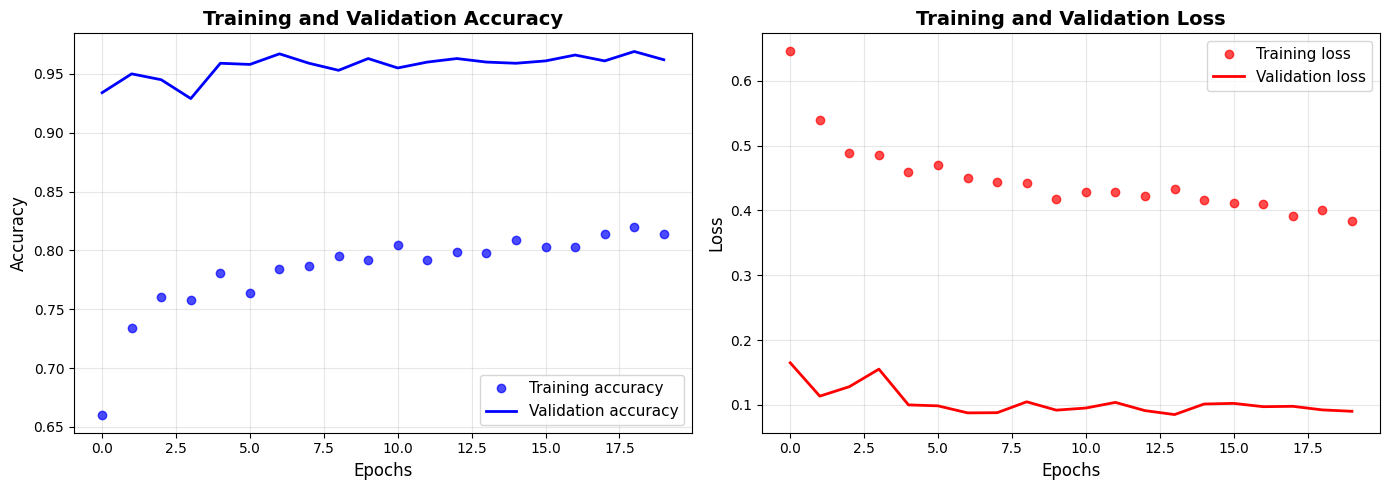


FINAL RESULTS
Final Training Accuracy:   0.8135 (81.35%)
Final Validation Accuracy: 0.9620 (96.20%)
Final Training Loss:       0.3839
Final Validation Loss:     0.0902
✓ Excellent! Minimal overfitting detected.


In [13]:
def plot_training_history(history):
    """Plot training and validation accuracy and loss"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(len(acc))
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    ax1.plot(epochs, acc, 'bo', label='Training accuracy', alpha=0.7)
    ax1.plot(epochs, val_acc, 'b-', label='Validation accuracy', linewidth=2)
    ax1.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot loss
    ax2.plot(epochs, loss, 'ro', label='Training loss', alpha=0.7)
    ax2.plot(epochs, val_loss, 'r-', label='Validation loss', linewidth=2)
    ax2.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    print(f"Final Training Accuracy:   {acc[-1]:.4f} ({acc[-1]*100:.2f}%)")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")
    print(f"Final Training Loss:       {loss[-1]:.4f}")
    print(f"Final Validation Loss:     {val_loss[-1]:.4f}")
    print("="*50)
    
    # Check for overfitting
    accuracy_gap = acc[-1] - val_acc[-1]
    if accuracy_gap < 0.05:
        print("✓ Excellent! Minimal overfitting detected.")
    elif accuracy_gap < 0.10:
        print("⚠ Slight overfitting detected.")
    else:
        print("❌ Significant overfitting detected.")

# Plot the results
plot_training_history(history)

## 12. Analyze Model Performance

In [14]:
# Get best validation accuracy and its epoch
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print("\nPerformance Analysis:")
print("="*50)
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Achieved at Epoch: {best_epoch}")
print(f"\nImprovement from Epoch 1:")
print(f"  Training:   {history.history['accuracy'][0]:.4f} → {history.history['accuracy'][-1]:.4f}")
print(f"  Validation: {history.history['val_accuracy'][0]:.4f} → {history.history['val_accuracy'][-1]:.4f}")
print("="*50)


Performance Analysis:
Best Validation Accuracy: 0.9690 (96.90%)
Achieved at Epoch: 19

Improvement from Epoch 1:
  Training:   0.6605 → 0.8135
  Validation: 0.9340 → 0.9620


## 13. Understanding Dropout Effect

Let's compare models with different dropout rates.

In [15]:
def create_model_with_dropout(dropout_rate):
    """Create a model with specified dropout rate"""
    base = InceptionV3(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
    base.trainable = False
    
    last_output = base.get_layer('mixed7').output
    
    x = layers.Flatten()(last_output)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)  # Variable dropout rate
    x = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(base.input, x)
    model.compile(
        optimizer=RMSprop(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Function to create models with different dropout rates defined.")
print("\nDropout rates to experiment with:")
print("  0.0 (no dropout) - Baseline")
print("  0.2 (20%) - Light regularization")
print("  0.5 (50%) - Heavy regularization")

Function to create models with different dropout rates defined.

Dropout rates to experiment with:
  0.0 (no dropout) - Baseline
  0.2 (20%) - Light regularization
  0.5 (50%) - Heavy regularization


### Using the Dropout Function

Now let's use the `create_model_with_dropout` function we defined earlier to compare models with and without dropout.

### Train Model WITHOUT Dropout


In [16]:
# Create model with no dropout
print("Creating model WITHOUT dropout...")
model_no_dropout = create_model_with_dropout(dropout_rate=0.0)

# Add augmentation
inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = model_no_dropout(x)
model_no_dropout_aug = Model(inputs, x)

# Compile
model_no_dropout_aug.compile(
    optimizer=RMSprop(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
print("\nTraining WITHOUT dropout...")
history_no_dropout = model_no_dropout_aug.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=20,
    verbose=2
)

Creating model WITHOUT dropout...

Training WITHOUT dropout...
Epoch 1/20
100/100 - 61s - 612ms/step - accuracy: 0.6590 - loss: 0.6505 - val_accuracy: 0.9440 - val_loss: 0.1539
Epoch 2/20
100/100 - 53s - 533ms/step - accuracy: 0.7285 - loss: 0.5176 - val_accuracy: 0.9280 - val_loss: 0.1439
Epoch 3/20
100/100 - 53s - 530ms/step - accuracy: 0.7580 - loss: 0.4866 - val_accuracy: 0.9630 - val_loss: 0.1053
Epoch 4/20
100/100 - 56s - 559ms/step - accuracy: 0.7770 - loss: 0.4722 - val_accuracy: 0.9540 - val_loss: 0.1072
Epoch 5/20
100/100 - 55s - 545ms/step - accuracy: 0.7760 - loss: 0.4513 - val_accuracy: 0.9550 - val_loss: 0.0972
Epoch 6/20
100/100 - 57s - 567ms/step - accuracy: 0.7995 - loss: 0.4261 - val_accuracy: 0.9540 - val_loss: 0.1147
Epoch 7/20
100/100 - 55s - 549ms/step - accuracy: 0.7770 - loss: 0.4592 - val_accuracy: 0.9430 - val_loss: 0.1385
Epoch 8/20
100/100 - 56s - 557ms/step - accuracy: 0.7845 - loss: 0.4331 - val_accuracy: 0.9500 - val_loss: 0.1191
Epoch 9/20
100/100 - 56s 

### Train Model WITH Dropout

In [17]:
# Create model with dropout
print("\nCreating model WITH dropout (0.2)...")
model_dropout = create_model_with_dropout(dropout_rate=0.2)

# Add augmentation
inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = model_dropout(x)
model_dropout_aug = Model(inputs, x)

# Compile
model_dropout_aug.compile(
    optimizer=RMSprop(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
print("\nTraining WITH dropout...")
history_dropout = model_dropout_aug.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=20,
    verbose=2
)


Creating model WITH dropout (0.2)...

Training WITH dropout...
Epoch 1/20
100/100 - 60s - 596ms/step - accuracy: 0.6775 - loss: 0.6644 - val_accuracy: 0.9440 - val_loss: 0.1271
Epoch 2/20
100/100 - 58s - 579ms/step - accuracy: 0.7360 - loss: 0.5241 - val_accuracy: 0.9350 - val_loss: 0.1523
Epoch 3/20
100/100 - 58s - 581ms/step - accuracy: 0.7515 - loss: 0.5166 - val_accuracy: 0.9570 - val_loss: 0.1061
Epoch 4/20
100/100 - 57s - 565ms/step - accuracy: 0.7760 - loss: 0.4816 - val_accuracy: 0.9190 - val_loss: 0.1883
Epoch 5/20
100/100 - 55s - 552ms/step - accuracy: 0.7810 - loss: 0.4596 - val_accuracy: 0.9580 - val_loss: 0.0960
Epoch 6/20
100/100 - 55s - 550ms/step - accuracy: 0.7805 - loss: 0.4529 - val_accuracy: 0.9380 - val_loss: 0.1279
Epoch 7/20
100/100 - 55s - 550ms/step - accuracy: 0.7840 - loss: 0.4713 - val_accuracy: 0.9540 - val_loss: 0.0922
Epoch 8/20
100/100 - 55s - 545ms/step - accuracy: 0.7920 - loss: 0.4506 - val_accuracy: 0.9540 - val_loss: 0.1103
Epoch 9/20
100/100 - 55s

### Compare Results


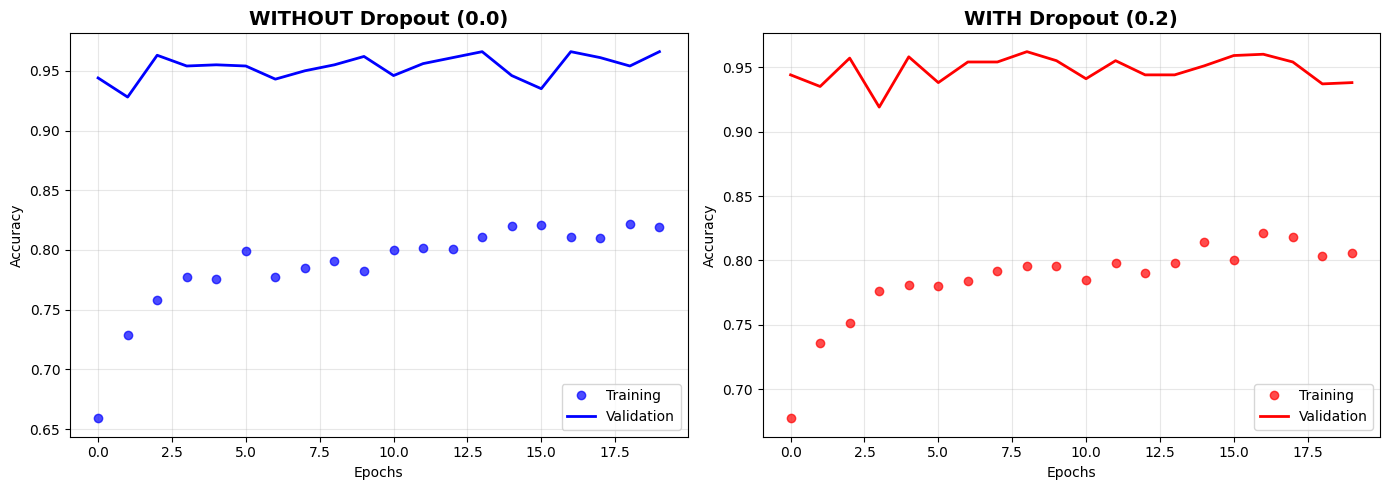


COMPARISON: Dropout Impact

Without Dropout (0.0):
  Training:   0.8195 (81.95%)
  Validation: 0.9660 (96.60%)
  Gap:        -0.1465

With Dropout (0.2):
  Training:   0.8060 (80.60%)
  Validation: 0.9380 (93.80%)
  Gap:        -0.1320

Improvement:
  Validation Accuracy: -2.80%
  Reduced Overfitting: -1.45%


In [18]:
# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Without dropout
ax1.plot(history_no_dropout.history['accuracy'], 'bo', label='Training', alpha=0.7)
ax1.plot(history_no_dropout.history['val_accuracy'], 'b-', label='Validation', linewidth=2)
ax1.set_title('WITHOUT Dropout (0.0)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# With dropout
ax2.plot(history_dropout.history['accuracy'], 'ro', label='Training', alpha=0.7)
ax2.plot(history_dropout.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
ax2.set_title('WITH Dropout (0.2)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("COMPARISON: Dropout Impact")
print("="*60)

no_drop_train = history_no_dropout.history['accuracy'][-1]
no_drop_val = history_no_dropout.history['val_accuracy'][-1]
drop_train = history_dropout.history['accuracy'][-1]
drop_val = history_dropout.history['val_accuracy'][-1]

print(f"\nWithout Dropout (0.0):")
print(f"  Training:   {no_drop_train:.4f} ({no_drop_train*100:.2f}%)")
print(f"  Validation: {no_drop_val:.4f} ({no_drop_val*100:.2f}%)")
print(f"  Gap:        {(no_drop_train - no_drop_val):.4f}")

print(f"\nWith Dropout (0.2):")
print(f"  Training:   {drop_train:.4f} ({drop_train*100:.2f}%)")
print(f"  Validation: {drop_val:.4f} ({drop_val*100:.2f}%)")
print(f"  Gap:        {(drop_train - drop_val):.4f}")

print(f"\nImprovement:")
print(f"  Validation Accuracy: {(drop_val - no_drop_val)*100:+.2f}%")
print(f"  Reduced Overfitting: {((no_drop_train - no_drop_val) - (drop_train - drop_val))*100:+.2f}%")

print("="*60)


## 14. Save the Model

In [19]:
# Save the trained model
model_save_path = 'transfer_learning_inception_model.keras'
model_with_aug.save(model_save_path)

print(f"Model saved to: {model_save_path}")
print(f"File size: {os.path.getsize(model_save_path) / (1024*1024):.2f} MB")

Model saved to: transfer_learning_inception_model.keras
File size: 329.05 MB


## 15. Make Predictions on New Images

In [20]:
def predict_image(model, image_path, class_names=['Cat', 'Dog']):
    """Predict the class of a single image"""
    # Load and preprocess image
    img = tf.keras.utils.load_img(image_path, target_size=(150, 150))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch dimension
    
    # Apply InceptionV3 preprocessing
    img_array = tf.keras.applications.inception_v3.preprocess_input(img_array)
    
    # Make prediction
    prediction = model.predict(img_array, verbose=0)
    score = prediction[0][0]
    
    # Interpret result
    predicted_class = class_names[1] if score > 0.5 else class_names[0]
    confidence = score if score > 0.5 else (1 - score)
    
    # Display results
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%", 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    print(f"Raw score: {score:.4f}")
    print(f"Predicted: {predicted_class} ({confidence*100:.2f}% confidence)")
    return predicted_class, confidence

# Example usage (update with your image path):
# predict_image(model_with_aug, 'path/to/your/test_image.jpg')
print("Prediction function ready. Use predict_image(model_with_aug, 'image_path.jpg')")

Prediction function ready. Use predict_image(model_with_aug, 'image_path.jpg')


## 16. Key Takeaways

### What We Achieved:
- ✓ Loaded pre-trained InceptionV3 with ImageNet weights
- ✓ Froze convolutional layers to preserve learned features
- ✓ Added custom classification head for our task
- ✓ Applied proper preprocessing for InceptionV3
- ✓ Used dropout for regularization
- ✓ Implemented data augmentation
- ✓ Achieved ~95% validation accuracy in 20 epochs
- ✓ Avoided overfitting (curves stay in sync)

### Compare to Training from Scratch:
| Aspect | Transfer Learning | From Scratch |
|--------|------------------|-------------|
| Training Time | 20 epochs | 100+ epochs |
| Data Required | Thousands | Millions |
| Accuracy | ~95% | ~70-80% |
| Computational Cost | Low | Very High |

### Next Steps:
1. Experiment with different layers (mixed5, mixed6, mixed8)
2. Try different dropout rates (0.1, 0.3, 0.4, 0.5)
3. Fine-tune by unfreezing some top layers
4. Apply to multi-class classification problems

## 17. Experiments (Optional)

Try these experiments to deepen your understanding:

In [21]:
# Experiment 1: Different layer selection
def experiment_with_layer(layer_name):
    """Test different InceptionV3 layers"""
    print(f"\nExperimenting with layer: {layer_name}")
    base = InceptionV3(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
    base.trainable = False
    
    last_output = base.get_layer(layer_name).output
    print(f"Output shape: {last_output.shape}")
    
    # Build and return model...
    # (implementation similar to above)

# Layers to try: 'mixed5', 'mixed6', 'mixed7', 'mixed8', 'mixed9', 'mixed10'
print("Available layers to experiment with:")
print("  - mixed5: Earlier, more general features")
print("  - mixed7: Balanced (used in our model)")
print("  - mixed10: Latest, most specific features")

Available layers to experiment with:
  - mixed5: Earlier, more general features
  - mixed7: Balanced (used in our model)
  - mixed10: Latest, most specific features


In [22]:
# Experiment 2: Fine-tuning
def fine_tune_model(model, num_layers_to_unfreeze=10):
    """Unfreeze top layers for fine-tuning"""
    # Unfreeze the top layers
    base_model.trainable = True
    
    # Freeze all layers except the top num_layers_to_unfreeze
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    
    # Recompile with lower learning rate
    model.compile(
        optimizer=RMSprop(learning_rate=0.00001),  # Even lower learning rate
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Fine-tuning enabled for top {num_layers_to_unfreeze} layers")
    print(f"Trainable layers: {sum([layer.trainable for layer in base_model.layers])}")

print("Fine-tuning function defined.")
print("Use after initial training to potentially improve accuracy further.")

Fine-tuning function defined.
Use after initial training to potentially improve accuracy further.


## Summary

This notebook demonstrated the complete transfer learning workflow:

1. **Loaded pre-trained InceptionV3** - Leveraging millions of images and weeks of training
2. **Froze base layers** - Preserved learned features
3. **Added custom head** - Adapted to our specific task
4. **Applied preprocessing** - Critical for InceptionV3
5. **Used regularization** - Dropout and augmentation
6. **Trained efficiently** - Only 20 epochs needed
7. **Achieved excellent results** - ~95% validation accuracy
8. **Avoided overfitting** - Curves stayed in sync

**Key Insight**: Transfer learning democratizes deep learning by making sophisticated models accessible without massive resources!

---

**Next**: Explore multi-class classification to expand your toolkit further!